In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from calcul_structure import *

In [2]:
## Propriété materiaux [N, m]
E = 1
I = 1
A = 1

#Element 1
L=1

# Ligne Influence Moment flechissant en  E
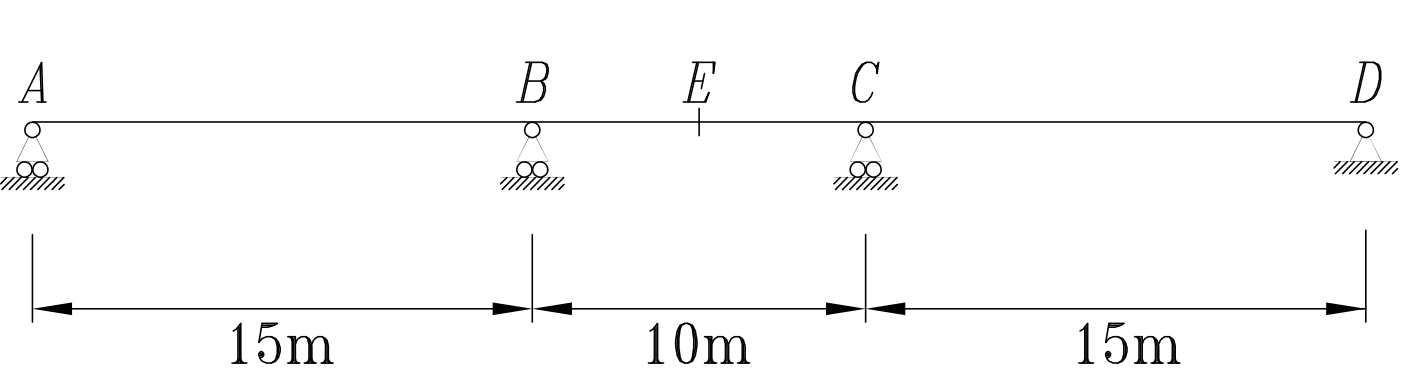

In [3]:
# Coordonnée éléments
XY = np.array([
     [0, 0], # Appui A
     [1, 0],
     [2, 0],
     [3, 0],
     [4, 0],
     [5, 0],
     [6, 0],
     [7, 0],
     [8, 0],
     [9, 0],
     [10,0],
     [11, 0],
     [12, 0],
     [13, 0],
     [14, 0],
     [15, 0], # Appui B
     [16, 0],
     [17, 0],
     [18, 0],
     [19, 0],
     [20,0], # Point E
     [21,0],
     [22,0],
     [23,0],
     [24,0],
     [25,0], # Appui C
     [25,0], # Dupliqué appui C
     [26,0],
     [27,0],
     [28,0],
     [29,0],
     [30,0],
     [31,0],
     [32,0],
     [33,0],
     [34,0],
     [35,0],
     [36,0],
     [37,0],
     [38,0],
     [39,0],
     [40,0], # Appui D
])

print(XY.shape)

(42, 2)


In [4]:
#Matrice de rigidité élémentaire en coordonnées locales
# Discretisation de la poutre en 8 element de longeur 5 m
mat_elem_local_1 = matrice_elementaire(E, I, A, L) # Matrice de rigidité Element 1

print(mat_elem_local_1)

[[  1.   0.   0.  -1.   0.   0.]
 [  0.  12.   6.   0. -12.   6.]
 [  0.   6.   4.   0.  -6.   2.]
 [ -1.   0.   0.   1.   0.   0.]
 [  0. -12.  -6.   0.  12.  -6.]
 [  0.   6.   2.   0.  -6.   4.]]


In [5]:
#Matrice de rotatio
rot_elem_1 = rotation_matrice(0) # Rotation Element 1

In [6]:
#Matrice de rigidité élémentaire en coordonnées locales
mat_elem_global_1 = np.matmul(np.matmul(np.transpose(rot_elem_1),mat_elem_local_1), rot_elem_1) # Matrice de rigidité Element 1

In [7]:
# Connection entre élément
# Degré de liberte de chaque élément de la forme
# LM[:, i] = [Uxi, Uyi, Thetai, Uxj, Uyj, Thetaj]
# Travée 1
LM = np.zeros((6, 41), dtype=int)
LM[:,0] =  [0, 0, 38,  0, 1, 39]
LM[:,1] =  [0, 1, 39,  0, 2, 40]    
LM[:,2] =  [0, 2, 40,  0, 3, 41]   
LM[:,3] =  [0, 3, 41,  0, 4, 42]
LM[:,4] =  [0, 4, 42,  0, 5, 43]   
LM[:,5] =  [0, 5, 43,  0, 6, 44]
LM[:,6] =  [0, 6, 44,  0, 7, 45]
LM[:,7] =  [0, 7, 45,  0, 8, 46]
LM[:,8] =  [0, 8, 46,  0, 9, 47]
LM[:,9] =  [0, 9, 47,  0, 10, 48]
LM[:,10] = [0, 10, 48, 0, 11, 49]
LM[:,11] = [0, 11, 49, 0, 12, 50]
LM[:,12] = [0, 12, 50, 0, 13, 51]
LM[:,13] = [0, 13, 51, 0, 14, 52]
LM[:,14] = [0, 14, 52, 0, 0, 53]

#Travée 2
LM[:,15] = [0, 0,  53, 0, 15, 54]
LM[:,16] = [0, 15, 54, 0, 16, 55]
LM[:,17] = [0, 16, 55, 0, 17, 56]
LM[:,18] = [0, 17, 56, 0, 18, 57]
LM[:,19] = [0, 18, 57, 0, 19, 58]
LM[:,20] = [0, 19, 58, 0, 20, 59]
LM[:,21] = [0, 20, 59, 0, 21, 60]
LM[:,22] = [0, 21, 60, 0, 22, 61]
LM[:,23] = [0, 22, 61, 0, 23, 62]
LM[:,24] = [0, 23, 62, 0, 0,  63]

#Travée 3
LM[:,25] = [0, 0,  64, 0, 24, 65]
LM[:,26] = [0, 24, 65, 0, 25, 66]
LM[:,27] = [0, 25, 66, 0, 26, 67]
LM[:,28] = [0, 26, 67, 0, 27, 68]
LM[:,29] = [0, 27, 68, 0, 28, 69]
LM[:,30] = [0, 28, 69, 0, 29, 70]
LM[:,31] = [0, 29, 70, 0, 30, 71]
LM[:,32] = [0, 30, 71, 0, 31, 72]
LM[:,33] = [0, 31, 72, 0, 32, 73]
LM[:,34] = [0, 32, 73, 0, 33, 74]
LM[:,35] = [0, 33, 74, 0, 34, 75]
LM[:,36] = [0, 34, 75, 0, 35, 76]
LM[:,37] = [0, 35, 76, 0, 36, 77]
LM[:,38] = [0, 36, 77, 0, 37, 78]
LM[:,39] = [0, 37, 78, 0, 38, 79]
LM[:,40] = [0, 38, 79, 0, 0,  79]

print(LM)


[[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14  0 15 16 17 18 19 20 21 22
  23  0 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38]
 [38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61
  62 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14  0 15 16 17 18 19 20 21 22 23
   0 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38  0]
 [39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62
  63 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 79]]


In [8]:
# Assemblage de la matrice de rigidité
K_global_2 = np.zeros((79, 79), dtype=np.float32)

for i in range(40):
    K_global_2 = assemblage_matrice_rigidite(LM, i, K_global_2, mat_elem_global_1)

print(K_global_2.shape)
np.linalg.inv(K_global_2)

(79, 79)


array([[ 3.6122074 ,  6.477659  ,  8.516267  , ...,  0.25096297,
         0.25096297,  0.25096297],
       [ 6.477659  , 12.127941  , 16.290133  , ...,  0.44103703,
         0.44103703,  0.44103703],
       [ 8.516267  , 16.290133  , 22.5792    , ...,  0.576     ,
         0.576     ,  0.576     ],
       ...,
       [ 0.25096297,  0.44103703,  0.576     , ...,  3.2855556 ,
         3.1855555 ,  3.1522222 ],
       [ 0.25096297,  0.44103703,  0.576     , ...,  3.1855555 ,
         4.0855556 ,  4.0522223 ],
       [ 0.25096297,  0.44103703,  0.576     , ...,  3.1522222 ,
         4.0522223 ,  5.018889  ]], dtype=float32)

In [9]:
#Vecteur de Force Nodale
P_global    = np.zeros(79)
P_global[62] = 1
P_global[63] = -1
print(P_global)

[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  1. -1.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.]


In [10]:
#Solution 
U = np.linalg.solve(K_global_2, P_global)
print(U)

[  0.24681481   0.54118519   0.864        1.19614815   1.51851852
   1.812        2.05748148   2.23585185   2.328        2.31481481
   2.17718519   1.896        1.45214815   0.82651852  -1.023
  -2.144       -3.241       -4.192       -4.875       -5.168
  -4.949       -4.096       -2.487       -4.49666667  -8.06
 -10.75666667 -12.65333333 -13.81666667 -14.31333333 -14.21
 -13.57333333 -12.47       -10.96666667  -9.13        -7.02666667
  -4.72333333  -2.28666667   0.21666667   0.27377778   0.31177778
   0.33066667   0.33044444   0.31111111   0.27266667   0.21511111
   0.13844444   0.04266667  -0.07222222  -0.20622222  -0.35933333
  -0.53155556  -0.72288889  -0.93333333  -1.09233333  -1.12933333
  -1.04433333  -0.83733333  -0.50833333  -0.05733333   0.51566667
   1.21066667   2.02766667   2.96666667  -4.98555556  -4.01888889
  -3.11888889  -2.28555556  -1.51888889  -0.81888889  -0.18555556
   0.38111111   0.88111111   1.31444444   1.68111111   1.98111111
   2.21444444   2.38111111   2.4

In [11]:
# Line d'Influence Muller-Breslaut
M1 = U[62]
M2 = U[63]
LI  = U/(abs(M1) + abs(M2)) #changer le signe de M2 et M2 pour une somme en valeur absolue
print(LI)
print(LI.shape)

[ 0.03103721  0.06805459  0.10864888  0.15041684  0.19095524  0.22786084
  0.25873038  0.28116064  0.29274836  0.29109031  0.27378324  0.23842392
  0.1826091   0.10393554 -0.12864329 -0.26961017 -0.40755903 -0.52714825
 -0.61303619 -0.64988124 -0.62234176 -0.51507615 -0.31274277 -0.56546039
 -1.01355316 -1.35266173 -1.59116948 -1.73745983 -1.79991617 -1.78692189
 -1.70686042 -1.56811513 -1.37906944 -1.14810675 -0.88361045 -0.59396395
 -0.28755065  0.02724605  0.03442783  0.03920637  0.04158167  0.04155372
  0.03912254  0.03428811  0.02705044  0.01740953  0.00536538 -0.00908202
 -0.02593265 -0.04518653 -0.06684365 -0.09090401 -0.11736761 -0.13736202
 -0.14201481 -0.13132597 -0.10529551 -0.06392343 -0.00720972  0.06484561
  0.15224256  0.25498114  0.37306134 -0.62693866 -0.50537935 -0.39220344
 -0.28741093 -0.19100182 -0.10297611 -0.0233338   0.04792511  0.11080061
  0.16529272  0.21140143  0.24912673  0.27846863  0.29942713  0.31200224
  0.31619394]
(79,)


(42,)
Ordonnée de la Ligne d'Influence : 
 [ 0.          0.03103721  0.06805459  0.10864888  0.15041684  0.19095524
  0.22786084  0.25873038  0.28116064  0.29274836  0.29109031  0.27378324
  0.23842392  0.1826091   0.10393554  0.         -0.12864329 -0.26961017
 -0.40755903 -0.52714825 -0.61303619 -0.64988124 -0.62234176 -0.51507615
 -0.31274277  0.          0.         -0.56546039 -1.01355316 -1.35266173
 -1.59116948 -1.73745983 -1.79991617 -1.78692189 -1.70686042 -1.56811513
 -1.37906944 -1.14810675 -0.88361045 -0.59396395 -0.28755065  0.        ]


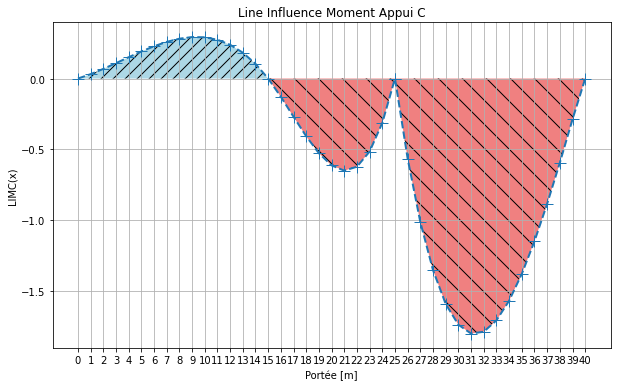

In [12]:
# Tracée ligne Influence
# Create the scatter plot
scale_factor = 1
x = scale_factor*XY[:, 0]

print(x.shape)

y = np.zeros((42,))
# appui A
y[0] = 0
# Noeud 1 à 14
y[1:15] = LI[0:14]
# Appuis B, seule rotation possible

y[15] = 0

# Noeud 4 : Point 15 à 23
y[16:25] = LI[14:23]

# # Appui C
y[25] = 0
y[26] = 0
# # Noeud 5, 6
y[27:41] = LI[23:37]
# # Noeud 7 reaction appui 0
y[41] = 0
print("Ordonnée de la Ligne d'Influence : \n",y)

plt.figure(figsize=(10,6))
plt.plot(x, y, '+--', linewidth=2, markersize=12)
plt.grid(True)
plt.xticks(np.arange(min(x), max(x)+1, 1.0))
# Fill the area above the line with a hashed pattern
plt.fill_between(x, y, np.zeros_like(y), where=(y >= 0), facecolor='lightblue', hatch='//')

# Fill the area below the line with a different hashed pattern
plt.fill_between(x, y, np.zeros_like(y), where=(y <= 0),  facecolor='lightcoral', hatch='\\')

# Add labels and title
plt.xlabel("Portée [m]")
plt.ylabel("LIMC(x)")
plt.title("Line Influence Moment Appui C")

# Show the plot
plt.show()

np.savetxt('./resultats/LIMC_resultats.csv', y, delimiter=',', fmt='%s')
